In [ ]:
import yfinance as yf
from datetime import datetime

# Get the stock quote for Apple using yfinance
df = yf.download('MSFT', start='2014-10-29', end=datetime.now())

# Display the data
print(df)

[*********************100%***********************]  1 of 1 completed

Price                       Adj Close       Close        High         Low  \
Ticker                           MSFT        MSFT        MSFT        MSFT   
Date                                                                        
2014-10-29 00:00:00+00:00   39.781357   46.619999   46.700001   46.340000   
2014-10-30 00:00:00+00:00   39.294971   46.049999   46.320000   45.770000   
2014-10-31 00:00:00+00:00   40.062950   46.950001   46.970001   46.480000   
2014-11-03 00:00:00+00:00   40.481071   47.439999   47.459999   46.730000   
2014-11-04 00:00:00+00:00   40.592007   47.570000   47.730000   47.250000   
...                               ...         ...         ...         ...   
2024-11-27 00:00:00+00:00  422.989990  422.989990  427.230011  422.019989   
2024-11-29 00:00:00+00:00  423.459991  423.459991  424.880005  417.799988   
2024-12-02 00:00:00+00:00  430.980011  430.980011  433.000000  421.309998   
2024-12-03 00:00:00+00:00  431.200012  431.200012  432.470001  427.739990   

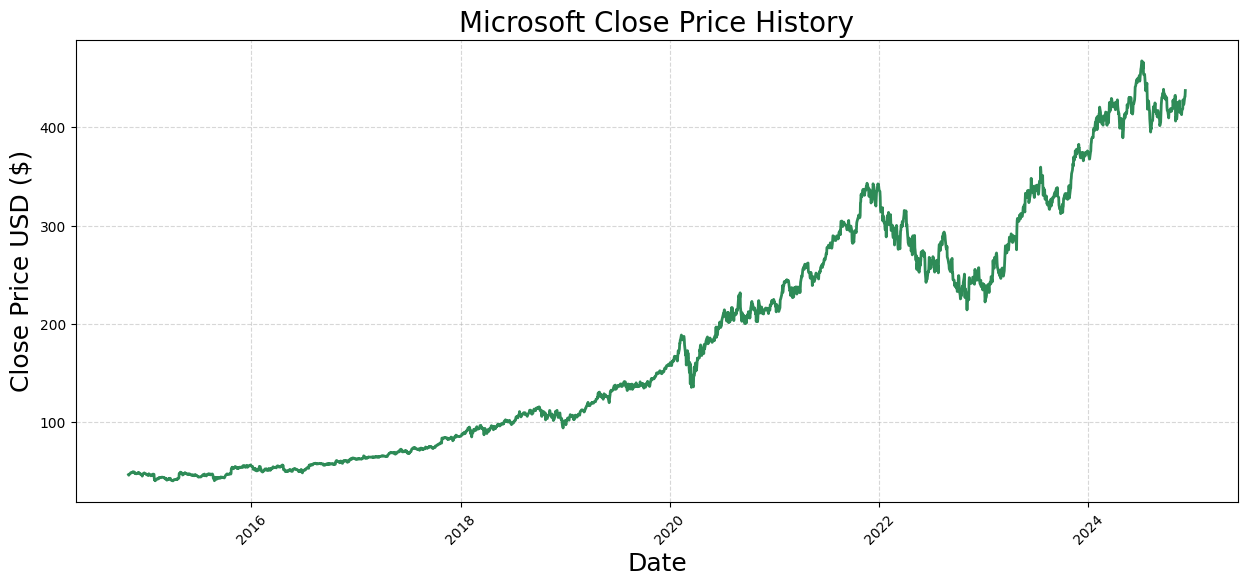

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.title('Microsoft Close Price History', fontsize=20)
plt.plot(df['Close'], color='seagreen', linewidth=2)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
import numpy as np  # Importing numpy if not already done

# Create a new dataframe with only the 'Close' column
data = df.filter(['Close'])

# Convert the dataframe to a numpy array
dataset = data.values

# Get the number of rows to train the model on (95% of dataset)
training_data_len = int(np.ceil(len(dataset) * 0.95))

training_data_len

2415

In [ ]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

# Ensure 'Close' column exists, if not, try 'close'
if 'Close' in df.columns:
    data = df[['Close']]  # Using double brackets to ensure a DataFrame is created
else:
    data = df[['close']]  # Trying 'close' as the column name

# Convert the dataframe to a numpy array
dataset = data.values

# Get the number of rows to train the model on (95% of dataset)
training_data_len = int(np.ceil(len(dataset) * 0.95))

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.01481498],
       [0.01348093],
       [0.01558733],
       ...,
       [0.91438672],
       [0.91490162],
       [0.92945916]])

In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.01481498, 0.01348093, 0.01558733, 0.01673414, 0.0170384 ,
       0.01771713, 0.0196831 , 0.01963629, 0.02012778, 0.02008097,
       0.01987033, 0.0218129 , 0.02174269, 0.02146184, 0.01977672,
       0.01855969, 0.0196831 , 0.01799798, 0.01708521, 0.01680436,
       0.01745968, 0.01760011, 0.01949586, 0.01912139, 0.01823203,
       0.02001076, 0.01902777, 0.01734266, 0.01708521, 0.01547031,
       0.01610222, 0.01558733, 0.014932  , 0.01139794, 0.0127554 ,
       0.01692138, 0.01724904, 0.01799798, 0.01909799, 0.01837245,
       0.01776394, 0.01675755, 0.01575116, 0.01441711, 0.01514264,
       0.01413626, 0.01254476, 0.01390221, 0.01708521, 0.01614903,
       0.01476817, 0.01420647, 0.01327029, 0.01214688, 0.01392562,
       0.01427668, 0.01317667, 0.01600861, 0.01612563, 0.01572775])]
[0.005546841459744753]

[array([0.01481498, 0.01348093, 0.01558733, 0.01673414, 0.0170384 ,
       0.01771713, 0.0196831 , 0.01963629, 0.02012778, 0.02008097,
       0.01987033, 0.0218129 , 0.0

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2355/2355 ━━━━━━━━━━━━━━━━━━━━ 147s 61ms/step - loss: 0.0026


In [ ]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step


34.48079264398984

<ipython-input-8-0cdd5e68a3a9>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


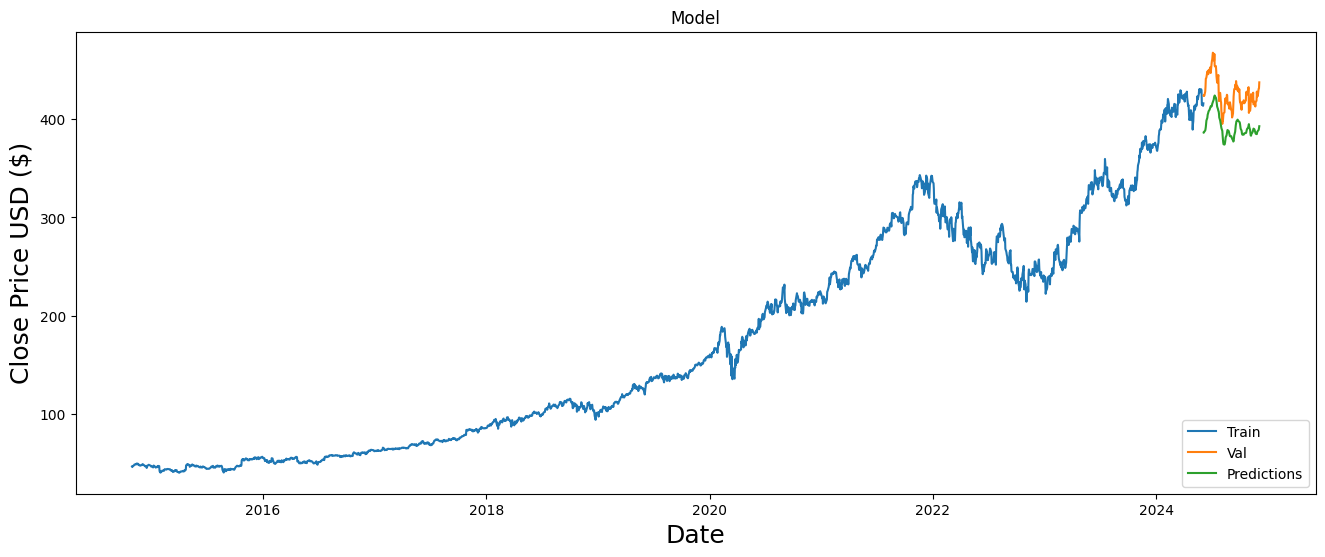

In [ ]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [ ]:
# Show the valid and predicted prices
valid

Price,Close,Predictions
Ticker,MSFT,
Date,,
2024-06-05 00:00:00+00:00,424.010010,386.324036
2024-06-06 00:00:00+00:00,424.519989,386.418884
2024-06-07 00:00:00+00:00,423.850006,387.321960
2024-06-10 00:00:00+00:00,427.869995,388.355530
2024-06-11 00:00:00+00:00,432.679993,389.887756
...,...,...
2024-11-27 00:00:00+00:00,422.989990,386.596283
2024-11-29 00:00:00+00:00,423.459991,387.949219


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)  # RMSE is the square root of MSE

# Display the metrics
print("Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Evaluation Metrics:
Mean Absolute Error (MAE): 33.43180474709338
Mean Squared Error (MSE): 1188.9250613578236
Root Mean Squared Error (RMSE): 34.48079264398984
